In [1]:
# Install required libraries (run once)
%pip install matplotlib seaborn ipywidgets scikit-learn pandas numpy

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Jupyter settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Interactive shell settings
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Widgets
from ipywidgets import interact

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
data = pd.read_csv('../Crop_recommendation.csv')
df = data
data.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


<Axes: xlabel='N', ylabel='Density'>

Text(0.5, 1.0, 'Ratio of Nitrogen')

Text(0.5, 0, '')

Text(0, 0.5, 'Density')

<Axes: xlabel='P', ylabel='Density'>

...

Text(0.5, 1.0, 'Ratio of Rainfall')

Text(0.5, 0, '')

Text(0, 0.5, 'Density')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

Text(0.5, 0.98, 'Distribution of agricultural conditions')

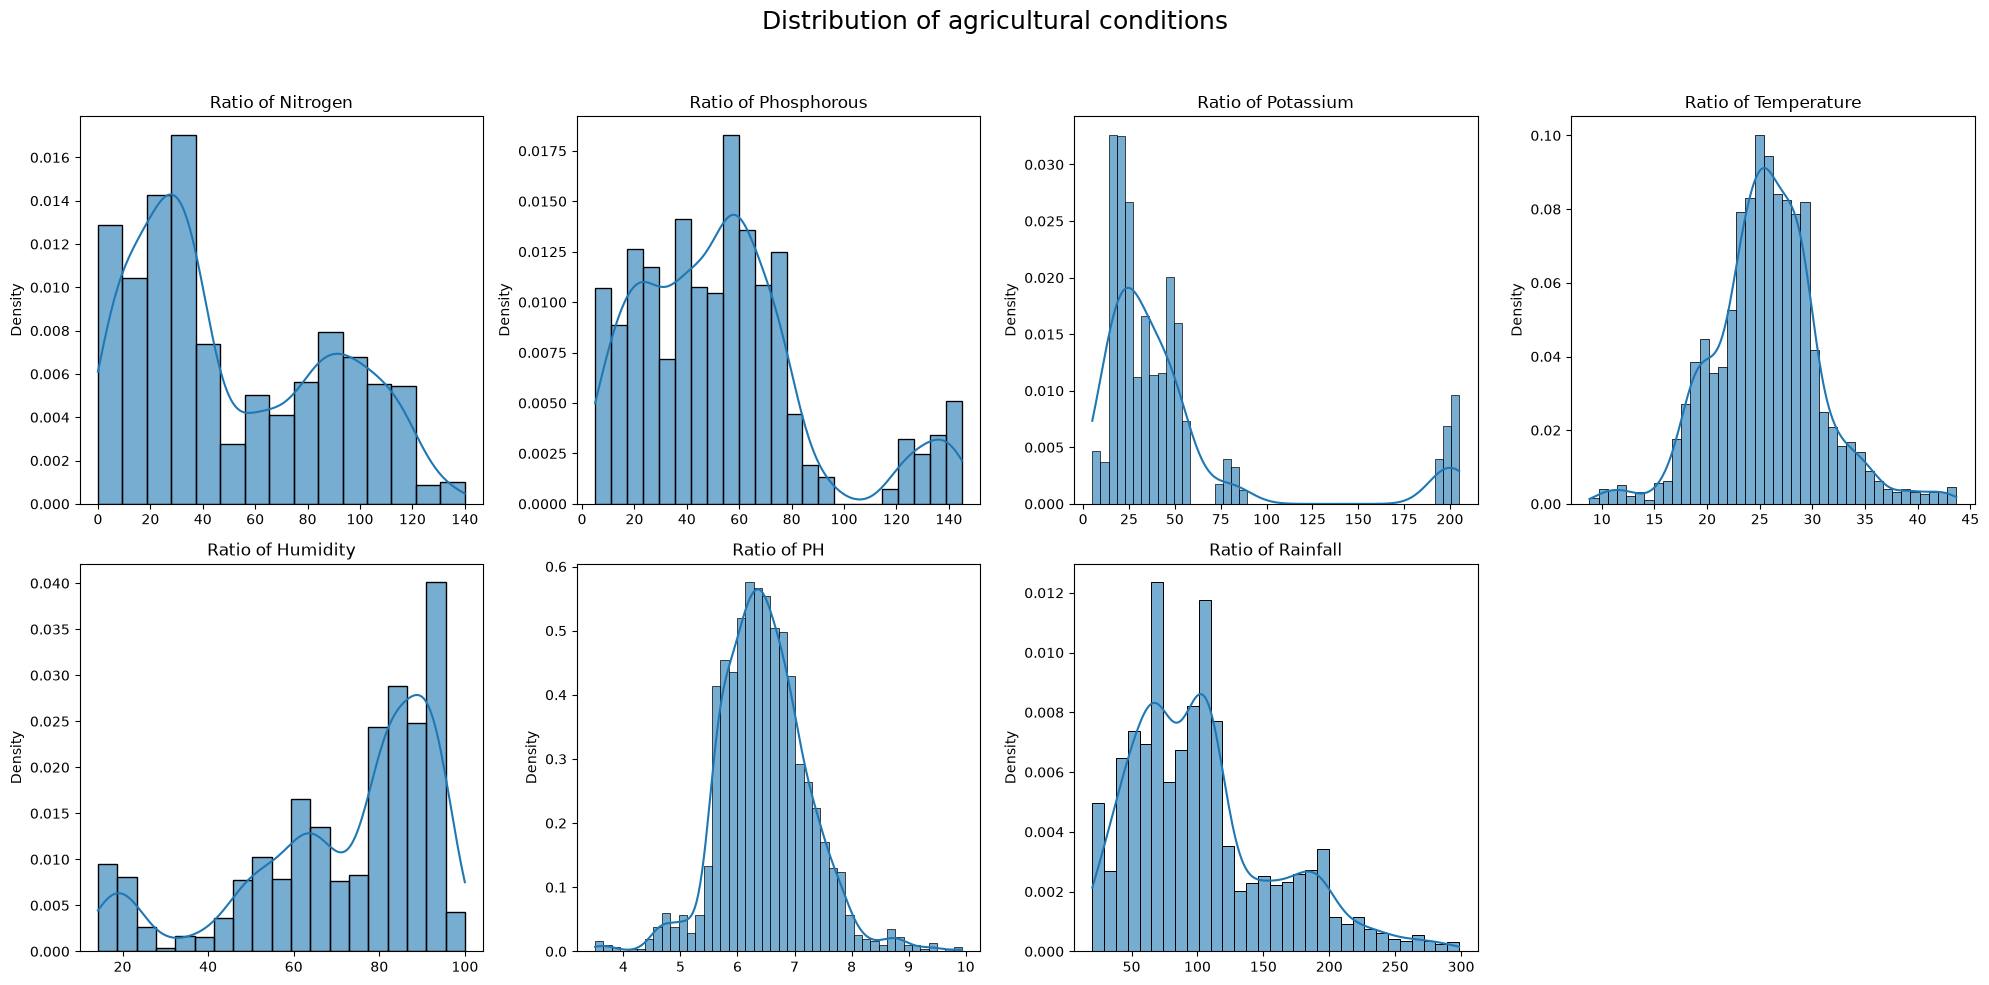

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
titles = [
    'Ratio of Nitrogen',
    'Ratio of Phosphorous',
    'Ratio of Potassium',
    'Ratio of Temperature',
    'Ratio of Humidity',
    'Ratio of PH',
    'Ratio of Rainfall'
]
for ax, col, title in zip(axes.flat, columns, titles):
    sns.histplot(data[col], kde=True, ax=ax, stat='density', alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Density')
for empty_ax in axes.flat[len(columns):]:
    empty_ax.axis('off')
plt.suptitle('Distribution of agricultural conditions', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<Axes: >

<Axes: xlabel='humidity', ylabel='label'>

Text(0.5, 0, 'humidity')

Text(0, 0.5, 'label')

Text(0.5, 1.0, 'Humidity vs Crop Label')

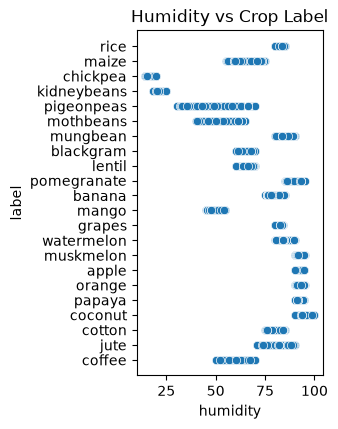

In [4]:
plt.subplot(2, 4, 7)
sns.scatterplot(x=data['humidity'], y=data['label'])
plt.xlabel('humidity')
plt.ylabel('label')
plt.title('Humidity vs Crop Label')
plt.tight_layout()
plt.show()


<Axes: ylabel='count'>

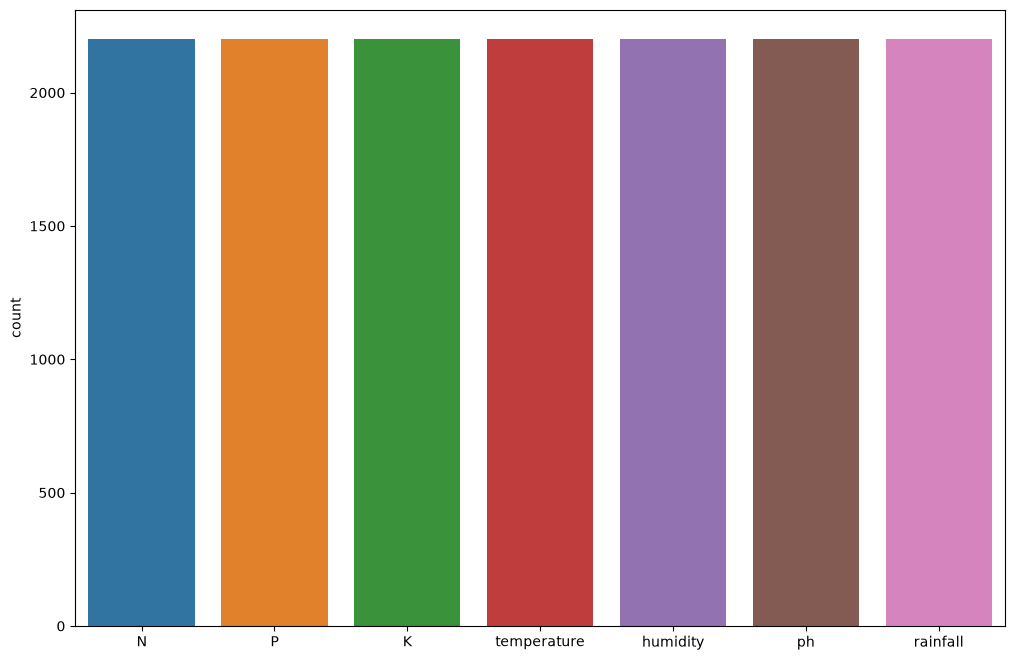

In [5]:
sns.countplot(data=data)
plt.show()
